**EE344 - Final Project**

Authors: Eeshani, Kuhu, Ruslana

**Question being answered:** Using audio features and popularity metrics from the 2023 Spotify streaming dataset, can we predict whether a song will be nominated for a Grammy in major song-related categories?
(Categories Considered: Song of the Year, Best R&B Song, Best Rap Song, Best Country Song, Best Song Written for Visual Media)

This file preprocesses the data, adds in feature engineering, and tests out an XGboost model with a reduced dataset that includes songs only within the 2024 Grammy eligibility timeframe. The idea here is that older songs or newer songs out of the time frame would never be nominated for the Grammys so this reduces the class imbalance by a lot hopefully.

**Result:**

test 1: keep all features in as is including the double chart_total and playlist_total which is redundant.
basic xgboost model result on test set: 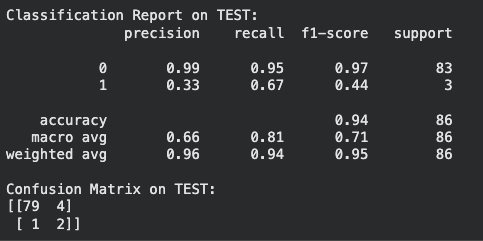

key insight here: the precision, recall, and F1 score went up from the previous tests on the larger dataset. The nominee percentage in a smaller dataset reduces the imbalance. Even though there are only about 300 rows now, there are a lot of features that could maybe offset that?

In [159]:
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

#imports for the preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
from sklearn.model_selection import GridSearchCV

In [160]:
# list of all nominees for 2024 best song in Song of the Year, Best R&B Song, Best Rap Song, Best Country Song, Best Song Written for Visual Media
nominee_list = [
  "Billie Eilish - What Was I Made For?",
  "Olivia Rodrigo - Vampire",
  "SZA - Kill Bill",
  "Miley Cyrus - Flowers",
  "Dua Lipa - Dance The Night",
  "Jon Batiste - Butterfly",
  "Taylor Swift - Anti-Hero",
  "Lana Del Rey - A&W",

  "SZA - Snooze",
  "Victoria Monét - On My Mama",
  "Coco Jones - ICU",
  "Robert Glasper - Back To Love",
  "Halle - Angel",

  "Killer Mike - SCIENTISTS & ENGINEERS",
  "Drake - Rich Flex",
  "Lil Uzi Vert - Just Wanna Rock",
  "Nicki Minaj - Barbie World",
  "Doja Cat - Attention",

  "Chris Stapleton - White Horse",
  "Morgan Wallen - Last Night",
  "Tyler Childers - In Your Love",
  "Zach Bryan - I Remember Everything",
  "Brandy Clark - Buried",

  "Rihanna - Lift Me Up",
  "Ryan Gosling - I'm Just Ken",

  "Billie Eilish - What Was I Made For? [From The Motion Picture \"Barbie\"]",
  "Dua Lipa - Dance The Night (From Barbie The Album)",
  "Nicki Minaj - Barbie World (with Aqua) [From Barbie The Album]",
  "Rihanna - Lift Me Up - From Black Panther: Wakanda Forever - Music From and Inspired By"
]

In [161]:
DATA_PATH = "/content/spotify-2023.csv"
df = pd.read_csv(DATA_PATH, encoding="latin1")

print(df.shape)
df.head()

(953, 24)


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [162]:
#add in a nominee column into the dataset before preprocessing anything
def normalize(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

#normalize nominee list
nominee_set = set(normalize(x) for x in nominee_list)

#combining artist and song into same format
df["song_artist"] = df["artist(s)_name"] + " - " + df["track_name"]

# normalize it
df["song_artist_norm"] = df["song_artist"].apply(normalize)

df["nominee"] = df["song_artist_norm"].isin(nominee_set).astype(int)

df[["artist(s)_name","track_name","nominee"]].head(20)

,artist(s)_name,track_name,nominee
0,"Latto, Jung Kook",Seven (feat. Latto) (Explicit Ver.),0
1,Myke Towers,LALA,0
2,Olivia Rodrigo,vampire,1
3,Taylor Swift,Cruel Summer,0
4,Bad Bunny,WHERE SHE GOES,0
5,"Dave, Central Cee",Sprinter,0
6,"Eslabon Armado, Peso Pluma",Ella Baila Sola,0
7,Quevedo,Columbia,0
8,Gunna,fukumean,0
9,"Peso Pluma, Yng Lvcas",La Bebe - Remix,0


In [163]:
#converting object types to ints
df['streams'] = pd.to_numeric(df['streams'], errors= 'coerce')
df['in_deezer_playlists'] = pd.to_numeric(df['in_deezer_playlists'], errors= 'coerce')
df['in_shazam_charts'] = pd.to_numeric(df['in_shazam_charts'], errors= 'coerce')

#sum of all the nulls in each col
df.isnull().sum()

,0
track_name,0
artist(s)_name,0
artist_count,0
released_year,0
released_month,0
released_day,0
in_spotify_playlists,0
in_spotify_charts,0
streams,1
in_apple_playlists,0


In [164]:
#fill in the null values to 0 if integer, NA if object
df['in_shazam_charts'] = df['in_shazam_charts'].fillna(0)
df['in_deezer_playlists'] = df['in_deezer_playlists'].fillna(0)
df['streams'] = df['streams'].fillna(0)
df['key']= df['key'].fillna('NA')

df.isnull().sum() #is 0 nulls now

,0
track_name,0
artist(s)_name,0
artist_count,0
released_year,0
released_month,0
released_day,0
in_spotify_playlists,0
in_spotify_charts,0
streams,0
in_apple_playlists,0


In [165]:
#remove the dates if not released between the grammy window October 1, 2022, through September 15, 2023
df["release_date"] = pd.to_datetime(
    df[["released_year", "released_month", "released_day"]]
    .rename(columns={
        "released_year": "year",
        "released_month": "month",
        "released_day": "day"
    })
)
# df[["released_year","released_month","released_day","release_date"]].head()

start_date = pd.Timestamp("2022-10-01")
end_date = pd.Timestamp("2023-09-15")

before = len(df)
df = df[(df["release_date"] >= start_date) & (df["release_date"] <= end_date)]
after = len(df)
print("Rows before:", before)
print("Rows after:", after)
print("Removed:", before - after)

print(df["release_date"].min())
print(df["release_date"].max())

Rows before: 953
Rows after: 286
Removed: 667
2022-10-03 00:00:00
2023-07-14 00:00:00


In [166]:
#drop dates because this is not timeseries data
df = df.drop(columns=[
    "released_year",
    "released_month",
    "released_day"])

#verify
df.head()

,track_name,artist(s)_name,artist_count,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,...,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,song_artist,song_artist_norm,nominee,release_date
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,553,147,141381703.0,43,263,45.0,10,...,89,83,31,0,8,4,"Latto, Jung Kook - Seven (feat. Latto) (Explic...",latto jung kook seven feat latto explicit ver,0,2023-07-14
1,LALA,Myke Towers,1,1474,48,133716286.0,48,126,58.0,14,...,61,74,7,0,10,4,Myke Towers - LALA,myke towers lala,0,2023-03-23
2,vampire,Olivia Rodrigo,1,1397,113,140003974.0,94,207,91.0,14,...,32,53,17,0,31,6,Olivia Rodrigo - vampire,olivia rodrigo vampire,1,2023-06-30
4,WHERE SHE GOES,Bad Bunny,1,3133,50,303236322.0,84,133,87.0,15,...,23,80,14,63,11,6,Bad Bunny - WHERE SHE GOES,bad bunny where she goes,0,2023-05-18
5,Sprinter,"Dave, Central Cee",2,2186,91,183706234.0,67,213,88.0,17,...,66,58,19,0,8,24,"Dave, Central Cee - Sprinter",dave central cee sprinter,0,2023-06-01


## Feature Engineering


In [167]:
#checking the spread of streams
print("Streams summary:")
print("Min streams:", df["streams"].min())
print("Max streams:", df["streams"].max())
print(df["streams"].describe())

#log transform streams
#reasoning behind it: stream counts are extremely skewed, so log compresses huge values
df["streams_log"] = np.log1p(df["streams"])

#add playlist_total feature
df["playlist_total"] = (
    df["in_spotify_playlists"] +
    df["in_apple_playlists"] +
    df["in_deezer_playlists"]
)

#add chart_total feature
df["chart_total"] = (
    df["in_spotify_charts"] +
    df["in_apple_charts"] +
    df["in_deezer_charts"] +
    df["in_shazam_charts"]
)

#quick check
print(df[["streams_log", "playlist_total", "chart_total"]].head())


Streams summary:
Min streams: 2762.0
Max streams: 1316855716.0
count    2.860000e+02
mean     1.875154e+08
std      1.748695e+08
min      2.762000e+03
25%      7.756811e+07
50%      1.376036e+08
75%      2.335755e+08
max      1.316856e+09
Name: streams, dtype: float64
   streams_log  playlist_total  chart_total
0    18.766974           641.0       1246.0
1    18.711231          1580.0        570.0
2    18.757181          1582.0       1283.0
4    19.530023          3304.0        623.0
5    19.028848          2341.0       1267.0


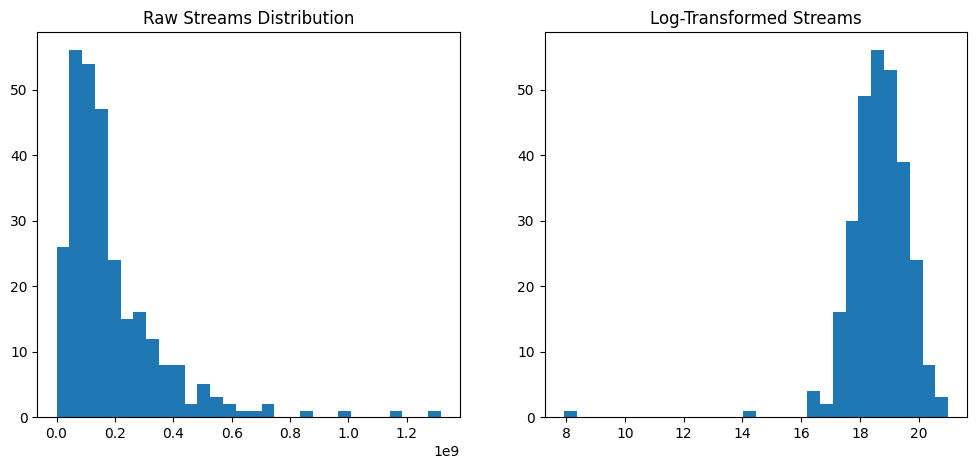

In [168]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df["streams"], bins=30)
plt.title("Raw Streams Distribution")

plt.subplot(1,2,2)
plt.hist(df["streams_log"], bins=30)
plt.title("Log-Transformed Streams")

plt.show()

In [169]:
df = df.drop(columns=["streams"])
df = df.drop(columns=["release_date"])

In [170]:
#one hot encode key and mode
cat_cols = ["key", "mode"]
id_cols = ["track_name", "artist(s)_name", "song_artist", "song_artist_norm"]
id_data = df[id_cols]
target = "nominee"

X_raw = df.drop(columns=id_cols + [target]).copy()
y = df[target].copy()

num_cols = [c for c in X_raw.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols)
    ],
    remainder="drop"
)

X_encoded = preprocessor.fit_transform(X_raw)
ohe = preprocessor.named_transformers_["cat"]
ohe_cols = ohe.get_feature_names_out(cat_cols)

final_cols = list(ohe_cols) + list(num_cols)

X = pd.DataFrame(X_encoded, columns=final_cols)
X.head()

,key_A,key_A#,key_B,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,...,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,streams_log,playlist_total,chart_total
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,80.0,89.0,83.0,31.0,0.0,8.0,4.0,18.766974,641.0,1246.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,71.0,61.0,74.0,7.0,0.0,10.0,4.0,18.711231,1580.0,570.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,51.0,32.0,53.0,17.0,0.0,31.0,6.0,18.757181,1582.0,1283.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,65.0,23.0,80.0,14.0,63.0,11.0,6.0,19.530023,3304.0,623.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,92.0,66.0,58.0,19.0,0.0,8.0,24.0,19.028848,2341.0,1267.0


In [171]:
print("Total songs:", len(df))
print("Nominee songs:", y.sum())
print("Non-nominee songs:", len(y) - y.sum())
print("Nominee proportion:", y.mean())

Total songs: 286
Nominee songs: 10
Non-nominee songs: 276
Nominee proportion: 0.03496503496503497


In [172]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key_A                 286 non-null    float64
 1   key_A#                286 non-null    float64
 2   key_B                 286 non-null    float64
 3   key_C#                286 non-null    float64
 4   key_D                 286 non-null    float64
 5   key_D#                286 non-null    float64
 6   key_E                 286 non-null    float64
 7   key_F                 286 non-null    float64
 8   key_F#                286 non-null    float64
 9   key_G                 286 non-null    float64
 10  key_G#                286 non-null    float64
 11  key_NA                286 non-null    float64
 12  mode_Major            286 non-null    float64
 13  mode_Minor            286 non-null    float64
 14  artist_count          286 non-null    float64
 15  in_spotify_playlists  2

## Model Training

In [173]:
!pip install xgboost

In [174]:
from xgboost import XGBClassifier

In [175]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Train positives:", y_train.sum())
print("Test positives:", y_test.sum())

Train positives: 7
Test positives: 3


In [176]:
#getting the imbalance weight
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 27.571428571428573


In [177]:
#simple xgboost model
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [178]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

In [179]:
print("Classification Report on TEST:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix on TEST:")
print(confusion_matrix(y_test, y_pred))

Classification Report on TEST:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97        83
           1       0.33      0.67      0.44         3

    accuracy                           0.94        86
   macro avg       0.66      0.81      0.71        86
weighted avg       0.96      0.94      0.95        86

Confusion Matrix on TEST:
[[79  4]
 [ 1  2]]


In [180]:
roc = roc_auc_score(y_test, y_prob)

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

print("ROC AUC:", roc)
print("PR AUC:", pr_auc)

ROC AUC: 0.7469879518072289
PR AUC: 0.2078766097634022


In [181]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.30]

for threshold in thresholds:
    y_pred_adj = (y_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, y_pred_adj, zero_division=0))
    print(confusion_matrix(y_test, y_pred_adj))


Threshold: 0.05
              precision    recall  f1-score   support

           0       0.99      0.93      0.96        83
           1       0.25      0.67      0.36         3

    accuracy                           0.92        86
   macro avg       0.62      0.80      0.66        86
weighted avg       0.96      0.92      0.94        86

[[77  6]
 [ 1  2]]

Threshold: 0.1
              precision    recall  f1-score   support

           0       0.99      0.94      0.96        83
           1       0.29      0.67      0.40         3

    accuracy                           0.93        86
   macro avg       0.64      0.80      0.68        86
weighted avg       0.96      0.93      0.94        86

[[78  5]
 [ 1  2]]

Threshold: 0.15
              precision    recall  f1-score   support

           0       0.99      0.94      0.96        83
           1       0.29      0.67      0.40         3

    accuracy                           0.93        86
   macro avg       0.64      0.80      0

In [182]:
importances = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances.head(15))

in_apple_playlists    0.439299
mode_Major            0.153350
energy_%              0.135744
acousticness_%        0.097990
in_spotify_charts     0.049813
speechiness_%         0.042411
valence_%             0.033733
streams_log           0.012601
chart_total           0.010270
bpm                   0.009671
danceability_%        0.007533
liveness_%            0.004124
in_apple_charts       0.003461
key_A                 0.000000
key_D#                0.000000
dtype: float32


In [183]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y)-y.sum())/y.sum(),
    eval_metric="logloss",
    random_state=42
)

roc_scores = cross_val_score(
    xgb_cv_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("ROC AUC per fold:", roc_scores)
print("Mean ROC AUC:", roc_scores.mean())

ROC AUC per fold: [1.         0.91818182 0.98181818 0.92727273 0.72727273]
Mean ROC AUC: 0.9109090909090909


## Grid Search through a large possible list of parameters

In [184]:
# from xgboost import XGBClassifier
# from sklearn.model_selection import GridSearchCV, StratifiedKFold
# from sklearn.metrics import classification_report, confusion_matrix, f1_score

# # train/test split first
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.3,
#     stratify=y,
#     random_state=42
# )

# scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

# xgb_base = XGBClassifier(
#     objective="binary:logistic",
#     scale_pos_weight=scale_pos_weight,
#     eval_metric="logloss",
#     random_state=42
# )

# param_grid = {
#     "n_estimators": [100, 200, 300],
#     "max_depth": [2, 3, 4, 5],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "subsample": [0.8, 1.0],
#     "colsample_bytree": [0.8, 1.0],
#     "min_child_weight": [1, 3, 5]
# }

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# grid = GridSearchCV(
#     estimator=xgb_base,
#     param_grid=param_grid,
#     scoring="f1",
#     cv=cv,
#     n_jobs=-1,
#     verbose=1
# )

# grid.fit(X_train, y_train)

# print("Best CV F1:", grid.best_score_)
# print("Best parameters:", grid.best_params_)

In [185]:
# best_xgb = grid.best_estimator_

# y_pred = best_xgb.predict(X_test)
# y_prob = best_xgb.predict_proba(X_test)[:, 1]

# print("Test Classification Report:")
# print(classification_report(y_test, y_pred, zero_division=0))

# print("Test Confusion Matrix:")
# print(confusion_matrix(y_test, y_pred))

# print("Test F1:", f1_score(y_test, y_pred, zero_division=0))

Did not work as anticipated, it overfit RIP

## More thorough evaluation of different hyperparameters.

In [186]:
#defining 10 model parameters
param_list = [
    {"max_depth":2, "learning_rate":0.05, "n_estimators":200},
    {"max_depth":3, "learning_rate":0.05, "n_estimators":200},
    {"max_depth":4, "learning_rate":0.05, "n_estimators":200},
    {"max_depth":3, "learning_rate":0.1, "n_estimators":200},
    {"max_depth":4, "learning_rate":0.1, "n_estimators":300},
    {"max_depth":5, "learning_rate":0.05, "n_estimators":300},
    {"max_depth":3, "learning_rate":0.03, "n_estimators":400},
    {"max_depth":4, "learning_rate":0.03, "n_estimators":400},
    {"max_depth":2, "learning_rate":0.1, "n_estimators":300},
    {"max_depth":5, "learning_rate":0.03, "n_estimators":500}
]

In [187]:
#defining empty array + a train test split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
results = []

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

#run through all the params list and evaluating them
for i, params in enumerate(param_list):

    model = XGBClassifier(
        **params,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    results.append({
        "model_id": i,
        "params": params,
        "f1": f1,
        "roc_auc": roc,
        "pr_auc": pr_auc
    })

In [188]:
results_df = pd.DataFrame(results)
#sorting the models to find the best f1 one
results_df.sort_values("f1", ascending=False)

,model_id,params,f1,roc_auc,pr_auc
1,1,"{'max_depth': 3, 'learning_rate': 0.05, 'n_est...",0.571429,0.787149,0.293326
5,5,"{'max_depth': 5, 'learning_rate': 0.05, 'n_est...",0.444444,0.726908,0.206863
9,9,"{'max_depth': 5, 'learning_rate': 0.03, 'n_est...",0.444444,0.763052,0.208913
6,6,"{'max_depth': 3, 'learning_rate': 0.03, 'n_est...",0.333333,0.775100,0.209708
7,7,"{'max_depth': 4, 'learning_rate': 0.03, 'n_est...",0.285714,0.783133,0.207511
2,2,"{'max_depth': 4, 'learning_rate': 0.05, 'n_est...",0.285714,0.783133,0.438066
4,4,"{'max_depth': 4, 'learning_rate': 0.1, 'n_esti...",0.285714,0.779116,0.179733
0,0,"{'max_depth': 2, 'learning_rate': 0.05, 'n_est...",0.000000,0.767068,0.178878
3,3,"{'max_depth': 3, 'learning_rate': 0.1, 'n_esti...",0.000000,0.720884,0.206615
8,8,"{'max_depth': 2, 'learning_rate': 0.1, 'n_esti...",0.000000,0.742972,0.177418


In [189]:
#sorting the models to find the best roc_auc
results_df.sort_values("roc_auc", ascending=False)

,model_id,params,f1,roc_auc,pr_auc
1,1,"{'max_depth': 3, 'learning_rate': 0.05, 'n_est...",0.571429,0.787149,0.293326
2,2,"{'max_depth': 4, 'learning_rate': 0.05, 'n_est...",0.285714,0.783133,0.438066
7,7,"{'max_depth': 4, 'learning_rate': 0.03, 'n_est...",0.285714,0.783133,0.207511
4,4,"{'max_depth': 4, 'learning_rate': 0.1, 'n_esti...",0.285714,0.779116,0.179733
6,6,"{'max_depth': 3, 'learning_rate': 0.03, 'n_est...",0.333333,0.775100,0.209708
0,0,"{'max_depth': 2, 'learning_rate': 0.05, 'n_est...",0.000000,0.767068,0.178878
9,9,"{'max_depth': 5, 'learning_rate': 0.03, 'n_est...",0.444444,0.763052,0.208913
8,8,"{'max_depth': 2, 'learning_rate': 0.1, 'n_esti...",0.000000,0.742972,0.177418
5,5,"{'max_depth': 5, 'learning_rate': 0.05, 'n_est...",0.444444,0.726908,0.206863
3,3,"{'max_depth': 3, 'learning_rate': 0.1, 'n_esti...",0.000000,0.720884,0.206615


In [190]:
best_row = results_df.sort_values("f1", ascending=False).iloc[0]

best_params = best_row["params"]

print(best_params)

{'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200}


In [191]:
#training on the best model identified
best_model = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [192]:
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98        83
           1       0.50      0.67      0.57         3

    accuracy                           0.97        86
   macro avg       0.74      0.82      0.78        86
weighted avg       0.97      0.97      0.97        86

[[81  2]
 [ 1  2]]


In [193]:
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances.head(15))

in_apple_playlists    0.336804
mode_Major            0.152856
energy_%              0.121515
artist_count          0.068842
valence_%             0.056328
chart_total           0.041435
in_spotify_charts     0.040250
speechiness_%         0.039016
streams_log           0.034251
bpm                   0.029606
acousticness_%        0.028834
key_F#                0.019963
danceability_%        0.011461
in_apple_charts       0.004867
in_shazam_charts      0.004451
dtype: float32


## Feature Engineering next steps for even better model performance

From best_model feature importances:

popularity wise:

*   in playlists
*   charts
*   streams


audio wise:

*   energy
*   valence
*   danceability
*   speechiness


Next test: feature reduction through feature selection with the best param model from above


In [367]:
candidate_features = [
    "streams_log",
    "chart_total",
    "in_spotify_charts",
    "in_apple_charts",
    "energy_%",
    "valence_%",
    "danceability_%",
    "speechiness_%",
    "acousticness_%",
    "bpm",
    "artist_count",
    "mode_Major"
]

In [368]:
from itertools import combinations

feature_combos = list(combinations(candidate_features, 10))

print("Total combinations:", len(feature_combos))

Total combinations: 66


In [369]:
#final test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#validation set from training data to be able to run validation training on
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,   # 0.25 of 0.8 og test set = 0.20 overall
    stratify=y_trainval,
    random_state=42
)

print("Train positives:", y_train.sum())
print("Validation positives:", y_val.sum())
print("Test positives:", y_test.sum())

Train positives: 6
Validation positives: 2
Test positives: 2


In [370]:
#train and validate all possible feature set models based on the val set before 1 final test set confirmation
results = []

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

for feats in feature_combos:
    feats = list(feats)

    X_train_subset = X_train[feats]
    X_val_subset = X_val[feats]

    model = XGBClassifier(
        max_depth=3,
        learning_rate=0.05,
        n_estimators=200,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    )


    model.fit(X_train_subset, y_train)

    y_val_pred = model.predict(X_val_subset)
    y_val_prob = model.predict_proba(X_val_subset)[:, 1]

    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    roc = roc_auc_score(y_val, y_val_prob)

    precision, recall, _ = precision_recall_curve(y_val, y_val_prob)
    pr_auc = auc(recall, precision)

    results.append({
        "features": tuple(feats),
        "val_f1": f1,
        "val_roc_auc": roc,
        "val_pr_auc": pr_auc
    })

results_df = pd.DataFrame(results)

results_sorted = results_df.sort_values(
    by=["val_pr_auc", "val_f1", "val_roc_auc"],
    ascending=[False, False, False]
)

print(results_sorted.head(10))

best_features = list(results_sorted.iloc[0]["features"])
print("Best features:", best_features)

                                             features    val_f1  val_roc_auc  \
50  (streams_log, in_spotify_charts, in_apple_char...  1.000000     1.000000   
26  (streams_log, chart_total, in_spotify_charts, ...  0.000000     1.000000   
65  (in_spotify_charts, in_apple_charts, energy_%,...  0.000000     1.000000   
20  (streams_log, chart_total, in_spotify_charts, ...  0.666667     0.990909   
13  (streams_log, chart_total, in_spotify_charts, ...  0.000000     0.990909   
14  (streams_log, chart_total, in_spotify_charts, ...  0.000000     0.990909   
41  (streams_log, chart_total, in_apple_charts, en...  0.000000     0.990909   
46  (streams_log, in_spotify_charts, in_apple_char...  0.500000     0.981818   
45  (streams_log, in_spotify_charts, in_apple_char...  0.400000     0.981818   
48  (streams_log, in_spotify_charts, in_apple_char...  0.400000     0.981818   

    val_pr_auc  
50    1.000000  
26    1.000000  
65    1.000000  
20    0.791667  
13    0.791667  
14    0.791667  


In [371]:
#run one final train test on the actual test set
best_features = list(results_sorted.iloc[0]["features"])
X_trainval_best = X_trainval[best_features]
X_test_best = X_test[best_features]

scale_pos_weight = (len(y_trainval) - y_trainval.sum()) / y_trainval.sum()

best_feature_model = XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

best_feature_model.fit(X_trainval_best, y_trainval)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [372]:
y_test_pred = best_feature_model.predict(X_test_best)
y_test_prob = best_feature_model.predict_proba(X_test_best)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

f1 = f1_score(y_test, y_test_pred, zero_division=0)
roc = roc_auc_score(y_test, y_test_prob)

precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc = auc(recall, precision)

print("Final test metrics:")
print("Test F1:", f1)
print("Test ROC AUC:", roc)
print("Test PR AUC:", pr_auc)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        56
           1       1.00      0.50      0.67         2

    accuracy                           0.98        58
   macro avg       0.99      0.75      0.83        58
weighted avg       0.98      0.98      0.98        58

Confusion Matrix:
[[56  0]
 [ 1  1]]
Final test metrics:
Test F1: 0.6666666666666666
Test ROC AUC: 0.9464285714285715
Test PR AUC: 0.5982142857142857




---


## train test split set with a different split for a final test and testing model generalizability


In [394]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Train positives:", y_train.sum())
print("Test positives:", y_test.sum())

Train positives: 7
Test positives: 3


In [395]:
best_features = list(results_sorted.iloc[2]["features"])
print("Best features:", best_features)
X_trainval_best = X_train[best_features]
X_test_best = X_test[best_features]

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

best_feature_model = XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

best_feature_model.fit(X_trainval_best, y_train)

Best features: ['in_spotify_charts', 'in_apple_charts', 'energy_%', 'valence_%', 'danceability_%', 'speechiness_%', 'acousticness_%', 'bpm', 'artist_count', 'mode_Major']


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [396]:
y_test_pred = best_feature_model.predict(X_test_best)
y_test_prob = best_feature_model.predict_proba(X_test_best)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

f1 = f1_score(y_test, y_test_pred, zero_division=0)
roc = roc_auc_score(y_test, y_test_prob)

precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc = auc(recall, precision)

print("Final test metrics:")
print("Test F1:", f1)
print("Test ROC AUC:", roc)
print("Test PR AUC:", pr_auc)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        83
           1       1.00      0.67      0.80         3

    accuracy                           0.99        86
   macro avg       0.99      0.83      0.90        86
weighted avg       0.99      0.99      0.99        86

Confusion Matrix:
[[83  0]
 [ 1  2]]
Final test metrics:
Test F1: 0.8
Test ROC AUC: 0.8393574297188755
Test PR AUC: 0.6862310815799187


In [397]:
importances = pd.Series(
    best_feature_model.feature_importances_,
    index=X_trainval_best.columns
).sort_values(ascending=False)

print(importances)

artist_count         0.190788
energy_%             0.180482
mode_Major           0.149777
danceability_%       0.115945
in_apple_charts      0.114472
speechiness_%        0.084293
valence_%            0.068643
bpm                  0.061470
in_spotify_charts    0.017926
acousticness_%       0.016205
dtype: float32


Model on Test:

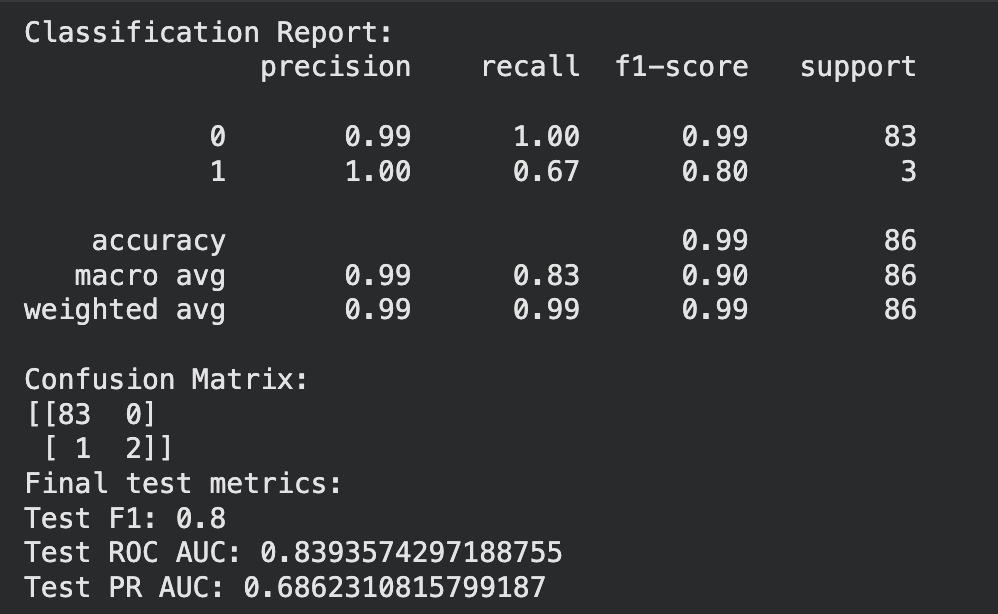


Features set: ['in_spotify_charts', 'in_apple_charts', 'energy_%', 'valence_%', 'danceability_%', 'speechiness_%', 'acousticness_%', 'bpm', 'artist_count', 'mode_Major']

XGBoost Hyperparameters:
    max_depth=3,
    learning_rate=0.05,
    n_estimators=200,

Key insights: Better PR auc on test

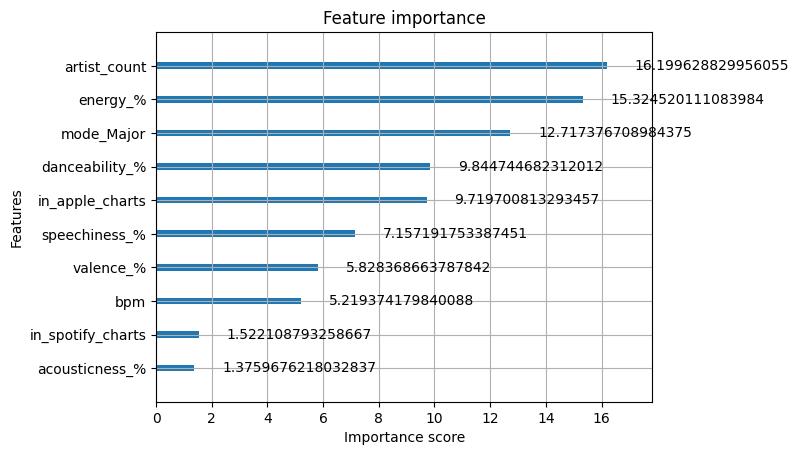

In [402]:
from xgboost import plot_importance


plot_importance(best_feature_model, importance_type="gain", max_num_features=10)
plt.show()